PAPER REPORTED VALUES
zeta     = 0.8222300000 rad
theta    = 1.1426600000 rad
phi      = 2.2642100000 rad
theta_p  = 0.7853900000 rad
phi_p    = 0.7501600000 rad

Tr(F^-1) at rounded paper values:
12.652741531552362
Optimization terminated successfully.
         Current function value: 12.652742
         Iterations: 176
         Function evaluations: 418

OPTIMIZED PARAMETERS
opt_zeta    = 0.822522751844614 rad
opt_theta   = 1.142887565656797 rad
opt_phi     = 2.264371096942413 rad
opt_theta_p = 0.785398162425017 rad
opt_phi_p   = 0.751024158027850 rad

In degrees:
zeta        = 47.127082234182708 deg
theta       = 65.482633970115259 deg
phi         = 129.738907106208842 deg
theta_p     = 44.999999944283765 deg
phi_p       = 43.030514567361976 deg

Tr(F^-1) =
12.652741525828048

Saved optimized parameters to:
optimal_parameters.json

FRAME AT OPTIMUM

F =
[[ 1.00000000e+00  2.41473870e-01 -1.79622549e-02  5.20417043e-18]
 [ 2.41473870e-01  2.43557250e-01  1.90389764e-02  1.16539809e-03

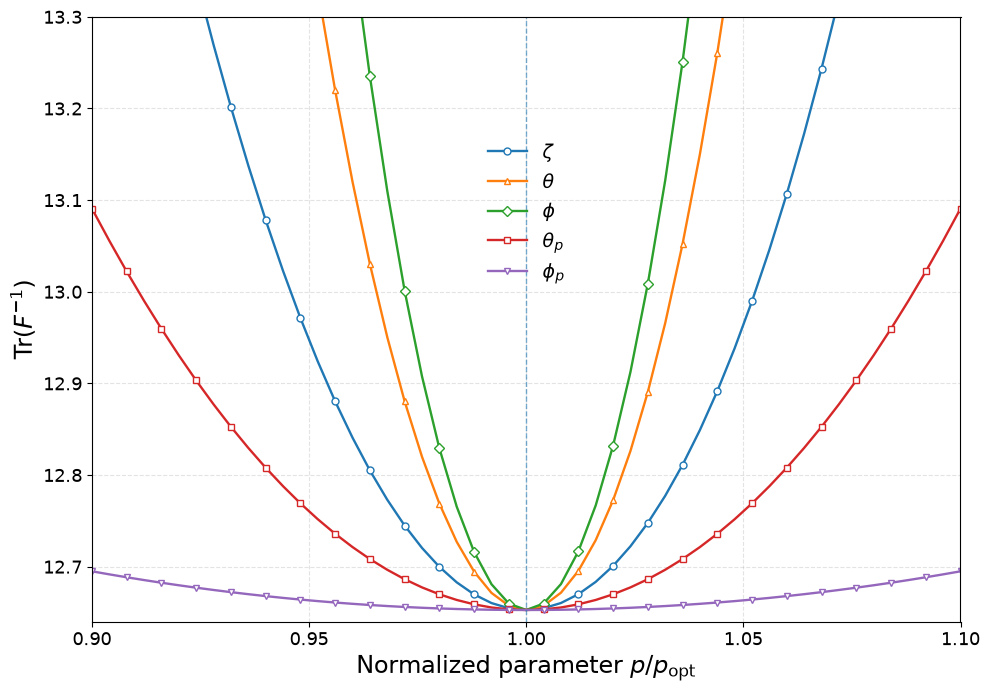

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import json


# ============================================================
# Fixed q-plate parameters
# ============================================================

alpha_1 = 105 * np.pi / 180
alpha_2 = 336 * np.pi / 180


# ============================================================
# Effective measurement operators from Eq. (S14)
# ============================================================

def effective_measurements(zeta, theta, phi, theta_p, phi_p):

    eta = zeta + phi - 2 * theta

    # Projection convention implicit in the displayed S13:
    # |psi> = cos(theta_p)|0> + exp(-i phi_p) sin(theta_p)|1>
    #
    # Therefore the bra contains +i phi_p, giving
    #
    # nu = 4 alpha_1 - 4 alpha_2 - 2 zeta + phi_p + 2 phi

    nu = (
        4 * alpha_1
        - 4 * alpha_2
        - 2 * zeta
        + phi_p
        + 2 * phi
    )

    C_eta = np.cos(eta)
    S_eta = np.sin(eta)

    C_tp = np.cos(theta_p)
    S_tp = np.sin(theta_p)

    S_2eta = np.sin(2 * eta)
    S_2tp = np.sin(2 * theta_p)

    # ------------------------------------------------------------
    # mu_1
    # ------------------------------------------------------------
    mu1 = 0.5 * np.array([
        [0, 0],
        [0, S_eta**2 * C_tp**2]
    ], dtype=complex)

    # ------------------------------------------------------------
    # mu_2
    # ------------------------------------------------------------
    mu2 = 0.5 * np.array([
        [S_eta**2 * S_tp**2, 0],
        [0, 0]
    ], dtype=complex)

    # ------------------------------------------------------------
    # mu_3
    # Corrected from V-tilde:
    # upper-right  ~ exp(+2 i zeta)
    # lower-left   ~ exp(-2 i zeta)
    # ------------------------------------------------------------
    mu3 = 0.5 * np.array([
        [
            S_eta**2 * C_tp**2,
            -0.5 * np.exp(+2j * zeta)
            * S_2eta * C_tp**2
        ],
        [
            -0.5 * np.exp(-2j * zeta)
            * S_2eta * C_tp**2,
            C_eta**2 * C_tp**2
        ]
    ], dtype=complex)

    # ------------------------------------------------------------
    # mu_4
    # Corrected from V-tilde:
    # upper-right  ~ exp(+i nu)
    # lower-left   ~ exp(-i nu)
    # ------------------------------------------------------------
    mu4 = 0.5 * np.array([
        [
            C_eta**2 * C_tp**2,
            0.5 * np.exp(+1j * nu)
            * C_eta**2 * S_2tp
        ],
        [
            0.5 * np.exp(-1j * nu)
            * C_eta**2 * S_2tp,
            C_eta**2 * S_tp**2
        ]
    ], dtype=complex)

    # ------------------------------------------------------------
    # mu_5
    # Corrected from V-tilde:
    # upper-right  ~ exp(+2 i zeta)
    # lower-left   ~ exp(-2 i zeta)
    # ------------------------------------------------------------
    mu5 = 0.5 * np.array([
        [
            C_eta**2 * S_tp**2,
            0.5 * np.exp(+2j * zeta)
            * S_2eta * S_tp**2
        ],
        [
            0.5 * np.exp(-2j * zeta)
            * S_2eta * S_tp**2,
            S_eta**2 * S_tp**2
        ]
    ], dtype=complex)

    return [mu1, mu2, mu3, mu4, mu5]


# ============================================================
# Pauli basis
# ============================================================

I = np.eye(2, dtype=complex)

sigma_x = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

sigma_y = np.array([
    [0, -1j],
    [1j, 0]
], dtype=complex)

sigma_z = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)

basis = [
    I / np.sqrt(2),
    sigma_x / np.sqrt(2),
    sigma_y / np.sqrt(2),
    sigma_z / np.sqrt(2)
]


# ============================================================
# Frame superoperator F
#
# Eq. (S9), with d = 2
# ============================================================

def frame_matrix(params):

    zeta, theta, phi, theta_p, phi_p = params

    mus = effective_measurements(
        zeta,
        theta,
        phi,
        theta_p,
        phi_p
    )

    F = np.zeros((4, 4), dtype=float)

    for i, B_i in enumerate(basis):

        for j, B_j in enumerate(basis):

            for mu in mus:

                tr_mu = np.trace(mu).real

                if tr_mu < 1e-14:
                    continue

                F[i, j] += (
                    np.trace(B_i @ mu)
                    * np.trace(mu @ B_j)
                    / (tr_mu / 2)
                ).real

    # Remove tiny numerical asymmetries
    F = 0.5 * (F + F.T)

    return F


# ============================================================
# Objective
# ============================================================

def objective(params):

    F = frame_matrix(params)

    eigvals = np.linalg.eigvalsh(F)

    if eigvals.min() <= 1e-12:
        return 1e12

    try:
        return np.trace(np.linalg.inv(F))
    except np.linalg.LinAlgError:
        return 1e12


# ============================================================
# Paper's reported values, Eq. (S16)
#
# Used as the starting point for local optimization
# ============================================================

paper_values = np.array([
    0.82223,
    1.14266,
    2.26421,
    0.78539,
    0.75016
])


# ============================================================
# Print paper values
# ============================================================

print("=" * 70)
print("PAPER REPORTED VALUES")
print("=" * 70)

names = [
    "zeta",
    "theta",
    "phi",
    "theta_p",
    "phi_p"
]

for name, value in zip(names, paper_values):
    print(f"{name:8s} = {value:.10f} rad")

print("\nTr(F^-1) at rounded paper values:")
print(objective(paper_values))


# ============================================================
# LOCAL OPTIMIZATION STARTING FROM PAPER VALUES
# ============================================================

result = minimize(
    objective,
    paper_values,
    method="Nelder-Mead",
    options={
        "maxiter": 50000,
        "xatol": 1e-12,
        "fatol": 1e-14,
        "disp": True
    }
)


# ============================================================
# OPTIMIZED PARAMETERS
# ============================================================

p_opt = result.x.copy()


# ============================================================
# Store individually
# ============================================================

opt_zeta = p_opt[0]
opt_theta = p_opt[1]
opt_phi = p_opt[2]
opt_theta_p = p_opt[3]
opt_phi_p = p_opt[4]


# ============================================================
# Print optimized values
# ============================================================

print("\n" + "=" * 70)
print("OPTIMIZED PARAMETERS")
print("=" * 70)

print(f"opt_zeta    = {opt_zeta:.15f} rad")
print(f"opt_theta   = {opt_theta:.15f} rad")
print(f"opt_phi     = {opt_phi:.15f} rad")
print(f"opt_theta_p = {opt_theta_p:.15f} rad")
print(f"opt_phi_p   = {opt_phi_p:.15f} rad")

print("\nIn degrees:")

print(f"zeta        = {np.degrees(opt_zeta):.15f} deg")
print(f"theta       = {np.degrees(opt_theta):.15f} deg")
print(f"phi         = {np.degrees(opt_phi):.15f} deg")
print(f"theta_p     = {np.degrees(opt_theta_p):.15f} deg")
print(f"phi_p       = {np.degrees(opt_phi_p):.15f} deg")

print("\nTr(F^-1) =")
print(f"{objective(p_opt):.15f}")


# ============================================================
# SAVE OPTIMIZED PARAMETERS TO JSON
# ============================================================

optimal_parameters = {
    "opt_zeta": float(opt_zeta),
    "opt_theta": float(opt_theta),
    "opt_phi": float(opt_phi),
    "opt_theta_p": float(opt_theta_p),
    "opt_phi_p": float(opt_phi_p)
}

with open("optimal_parameters_corrected.json", "w") as f:
    json.dump(
        optimal_parameters,
        f,
        indent=4
    )

print("\nSaved optimized parameters to:")
print("optimal_parameters.json")


# ============================================================
# Frame at optimum
# ============================================================

F_opt = frame_matrix(p_opt)

eigvals = np.linalg.eigvalsh(F_opt)

print("\n" + "=" * 70)
print("FRAME AT OPTIMUM")
print("=" * 70)

print("\nF =")
print(F_opt)

print("\nEigenvalues =")
print(eigvals)

print("\nTr(F^-1) =")
print(np.trace(np.linalg.inv(F_opt)))


# ============================================================
# FIGURE S1
#
# Each parameter is perturbed independently.
# All other parameters remain at the optimum.
#
# x-axis = p / p_opt
# ============================================================

x = np.linspace(0.90, 1.10, 51)

param_labels = [
    r'$\zeta$',
    r'$\theta$',
    r'$\phi$',
    r'$\theta_p$',
    r'$\phi_p$'
]

markers = [
    'o',
    '^',
    'D',
    's',
    'v'
]


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)


for p_idx in range(5):

    values = []

    for scale in x:

        # Copy optimized parameters
        params = p_opt.copy()

        # Perturb only one parameter
        params[p_idx] = p_opt[p_idx] * scale

        # Calculate objective
        values.append(
            objective(params)
        )

    values = np.asarray(values)

    ax.plot(
        x,
        values,
        linewidth=1.7,
        marker=markers[p_idx],
        markersize=5,
        markerfacecolor='white',
        markeredgewidth=1.0,
        markevery=2,
        label=param_labels[p_idx]
    )


# ============================================================
# Reference line
# ============================================================

ax.axvline(
    1.0,
    linestyle='--',
    linewidth=1.0,
    alpha=0.6
)


# ============================================================
# Axis settings
# ============================================================

ax.set_xlim(0.90, 1.10)

ax.set_ylim(12.64, 13.30)

ax.set_xticks([
    0.90,
    0.95,
    1.00,
    1.05,
    1.10
])

ax.set_yticks([
    12.7,
    12.8,
    12.9,
    13.0,
    13.1,
    13.2,
    13.3
])


# ============================================================
# Labels
# ============================================================

ax.set_xlabel(
    r'Normalized parameter $p/p_{\mathrm{opt}}$',
    fontsize=17
)

ax.set_ylabel(
    r'$\mathrm{Tr}(F^{-1})$',
    fontsize=17
)


# ============================================================
# Grid
# ============================================================

ax.grid(
    True,
    linestyle='--',
    alpha=0.35
)


# ============================================================
# Legend
# ============================================================

ax.legend(
    fontsize=14,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.50, 0.82)
)


# ============================================================
# Tick size
# ============================================================

ax.tick_params(
    axis='both',
    labelsize=13
)


# ============================================================
# Layout
# ============================================================

plt.tight_layout()

plt.show()